# A Trilha da <span style="color:yellow">Acadêmica</span> - <span style="color:red">GANs</span>

========================================================

# Introdução

As redes neurais generativas representam uma classe de modelos de aprendizado de máquina capazes de aprender padrões complexos a partir de dados e, a partir disso, gerar novas amostras semelhantes às observadas. Diferentemente de modelos discriminativos, que focam em classificar ou prever rótulos, essas redes aprendem a distribuição dos dados, permitindo a criação de imagens, textos, sons e outros tipos de conteúdo sintético. Esse campo tem ganhado destaque devido ao seu potencial em áreas como visão computacional, geração de mídia e simulações [1].

Dentro desse contexto, destacam-se as **GANs (Generative Adversarial Networks)**, que correspondem a um *framework* de algoritmos dentro das redes neurais generativas. As GANs são baseadas na interação entre dois componentes: o Gerador e o Discriminador. O Gerador tem como objetivo criar dados sintéticos que se assemelhem aos reais, enquanto o Discriminador tenta distinguir entre dados reais e falsos. Esse processo adversarial faz com que ambos os modelos melhorem progressivamente, resultando em gerações cada vez mais realistas. O conceito central por trás do treino dessas redes está justamente nessa dinâmica de competição, que leva ao aprendizado eficiente da distribuição dos dados [1, 2].

Neste trabalho, serão apresentados os principais conceitos relacionados às GANs, incluindo o que são e como funcionam, além do princípio de treinamento dessas arquiteturas. Também será discutido o papel do Discriminador e do Gerador, detalhando suas funções e funcionamento dentro das redes. Ademais, serão explorados os tipos de problemas que essas redes podem resolver e como implementar e treinar uma rede neural generativa utilizando o `PyTorch`. Por fim, serão apresentados exemplos didáticos de diferentes arquiteturas dessas redes, a fim de facilitar a compreensão dos conceitos abordados.

Como complemento, há uma seção bônus ao final do trabalho apresentando um exemplo de rede generativa aplicada ao contexto de imagens de personagens de anime, com o objetivo de ilustrar uma aplicação prática adicional das GANs em um domínio visual mais específico.

# O que exatamente são essas redes generativas?

> "The coolest idea in deep learning in the last 20 years."
> 
> — Yann LeCun à respeito das GANs [3].

As GANs pertencem à classe dos modelos generativos, um conjunto de algoritmos inseridos no campo do aprendizado não-supervisionado. Esses modelos têm como objetivo aprender a estrutura subjacente dos dados, isto é, a forma como eles estão distribuídos, sem a necessidade de rótulos explícitos. Em termos probabilísticos, modelos generativos buscam aprender a distribuição dos dados $p(x)$ (ou $p(x,y)$, no caso de dados com múltiplas classes), o que permite não apenas compreender os dados, mas também gerar novas amostras sintéticas semelhantes às originais [2].

Essa abordagem contrasta com os modelos discriminativos, comuns no aprendizado supervisionado, que aprendem uma função do tipo $y = f(x)$ a partir de dados rotulados. Esses modelos focam em estimar a probabilidade condicional $p(y∣x)$, ou seja, a probabilidade de um determinado rótulo dado uma entrada. Embora sejam altamente eficazes para tarefas como classificação e regressão, modelos discriminativos não são projetados para gerar novos dados diretamente, já que não capturam explicitamente a distribuição completa dos dados de entrada [2].

Nesse contexto, as GANs se destacam por sua capacidade de modelar dados de alta dimensão, como imagens, de forma eficiente, sendo amplamente utilizadas em tarefas de geração de conteúdo sintético. Apesar de seu sucesso, elas não são o único tipo de modelo generativo, existem outras abordagens como as Variational Autoencoders (VAEs), modelos autoregressivos e os modelos de difusão. De forma geral, modelos generativos oferecem uma perspectiva complementar aos métodos discriminativos, sendo particularmente úteis quando o objetivo é compreender e reproduzir a estrutura dos dados [1, 4].

# Arquitetura e funcionamento geral de uma GAN

<img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*5rMmuXmAquGTT-odw-bOpw.jpeg" width="600">

**Figura 1.** Estrutura geral de uma Generative Adversarial Network (GAN).  
**Fonte:** Diego Gomez Mosquera - https://medium.com/ai-society/gans-from-scratch-1-a-deep-introduction-with-code-in-pytorch-and-tensorflow-cb03cdcdba0f

Uma GAN é composta por dois modelos neurais distintos: o **Gerador** e o **Discriminador**, organizados em uma estrutura adversarial [Figura 1]. Cada um desempenha um papel específico, e o comportamento do sistema emerge da interação competitiva entre esses dois componentes.

O **Gerador** tem como objetivo criar dados sintéticos a partir de entradas aleatórias. Ele recebe um ruído simples, e aprende a transformá-lo em algo que se aproxime dos dados reais do conjunto de treinamento, como imagens, textos ou sinais. Nesse contexto adversarial, seu papel é produzir amostras suficientemente realistas para enganar o Discriminador [2, 4].

O **Discriminador**, por sua vez, atua como um avaliador desses dados. Ele recebe tanto exemplos reais quanto gerados e tenta distingui-los, classificando cada entrada como verdadeira ou falsa. Assim, o ponto central da arquitetura está na relação entre esses dois modelos. O Gerador melhora ao tentar enganar o Discriminador, enquanto o Discriminador evolui ao tentar evitar ser enganado. Esse confronto direto estabelece um processo adversarial, frequentemente descrito como uma *competição* entre esses dois agentes [2, 4].

# Qual o conceito por trás do treino desse tipo de rede?

O treinamento de uma GAN segue um processo iterativo baseado na alternância entre o **Discriminador** e o **Gerador**:

Inicialmente, amostras de dados reais são selecionadas do conjunto de treinamento, enquanto um conjunto de vetores aleatórios é utilizado para gerar dados sintéticos. Essas duas fontes de dados são então usadas para treinar o Discriminador, que ajusta seus parâmetros para melhorar sua capacidade de distinguir entre exemplos reais e falsos.

Em seguida, um novo conjunto de ruído aleatório é gerado e utilizado pelo Gerador para produzir novas amostras sintéticas. Essas amostras são avaliadas pelo Discriminador, e o *feedback* obtido é utilizado para ajustar o Gerador, com o objetivo de tornar seus dados mais convincentes.

Esse ciclo de amostragem, atualização do Discriminador e atualização do Gerador é repetido ao longo das épocas. Esse processo iterativo força ambos os modelos a se refinarem, resultando em uma melhoria progressiva na qualidade das amostras geradas [2, 4].

# Modelagem matemática de uma GAN

O texto abaixo busca explicar, de forma matemática, o funcionamento do Gerador e do Discriminador em uma GAN. Caso o leitor não tenha interesse nesse nível de detalhamento, pode optar por pular esta seção. Este trecho foi baseado na referência [2].

------------------------------------------------------------------------------

O Gerador é representado por uma função parametrizada $ G(z; \theta_G) $, onde $ z \sim p_z(z) $ é um vetor de ruído amostrado de uma distribuição simples e $ \theta_G $ representa os parâmetros da rede. Essa função mapeia o espaço latente para o espaço dos dados, gerando amostras sintéticas $ G(z) $.

O Discriminador é modelado por uma função $ D(x; \theta_D) $, que recebe uma amostra $ x $ e retorna um valor no intervalo $(0,1)$, interpretado como a probabilidade de que $ x $ pertença à distribuição dos dados reais. Os parâmetros $ \theta_D $ são ajustados durante o treinamento para melhorar sua capacidade de classificação.

O treinamento do Discriminador consiste em maximizar sua capacidade de distinguir dados reais de dados gerados. Isso implica aumentar $ D(x) $ para amostras reais $ x \sim p_{data} $ e reduzir $ D(G(z)) $ para amostras sintéticas produzidas pelo Gerador.

Por outro lado, o Gerador é treinado para enganar o Discriminador, ajustando seus parâmetros de forma a aumentar $ D(G(z)) $, ou seja, a probabilidade de que suas amostras sejam classificadas como reais.

Na prática, não se utilizam diretamente as probabilidades como função de otimização. Em vez disso, são empregadas **funções de perda logarítmicas**. Essa escolha é importante porque o uso do log torna o treinamento mais estável numericamente e faz com que erros cometidos com alta confiança sejam penalizados de forma mais intensa, o que melhora o ajuste dos parâmetros durante o aprendizado.

Esse processo conjunto é formalizado como um jogo *minmax* entre os dois modelos, descrito pela função:

$$
\min_G \max_D V(D, G) =
\mathbb{E}_{x \sim p_{data}}[\log D(x)] +
\mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]
$$

Nesse cenário, o Discriminador busca maximizar a função objetivo, enquanto o Gerador busca minimizá-la. O equilíbrio ideal ocorre quando o Gerador reproduz a distribuição dos dados reais e o Discriminador não consegue mais distinguir entre entradas reais e geradas.

# Que tipo de problema uma GAN pode resolver?

As GANs possuem diversas aplicações em inteligência artificial e computação gráfica, como pode ser visto em [5]. Alguns exemplos incluem: 

- Geração de imagens a partir de texto (Text-to-Image);
- Super-resolução de imagens;
- Transferência de domínio (Style Transfer);
- Edição e preenchimento de imagens (Image Inpainting);
- Geração de dados sintéticos.

# Enfim...a implementação de uma GAN!

Após todos esses textos com a explicação teórica de uma GAN, chegou a hora de colocar a mão na massa e programá-las!

Nesta atividade, serão implementadas três arquiteturas de GAN de forma didática: a **Vanilla GAN**, a **CGAN (Conditional GAN)** e a **DCGAN (Deep Convolutional GAN)**. Essas variações permitem observar, na prática, como pequenas modificações na estrutura do modelo impactam diretamente o uso desse tipo de rede neural.

# Importações

Na célula abaixo, encontram-se as importações necessárias para este trabalho.

In [1]:
import torch
import sys
from torch import nn, optim
from PIL import Image as PILImage
from torch.autograd.variable import Variable
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader
from IPython.display import display, Image, clear_output, Video
import os
import imageio.v2 as imageio
from io import BytesIO
from tensorboard import program
import pandas as pd
import matplotlib.pyplot as plt

Também utilizaremos um `Logger` localizado em `utils.py`, criado por Diego Gomez [2], entretanto com leves alterações de minha parte. Não é necessário compreender sua implementação interna, pois ele tem apenas a função de auxiliar na visualização do comportamento das redes.

In [2]:
from utils import Logger

# <span style="color:red"> Vanilla GAN</span>

As **Vanilla GANs (VGAN)** representam a formulação original das redes adversárias generativas, proposta por Ian Goodfellow e colaboradores em 2014 [6]. O modelo introduz um esquema de aprendizado adversarial entre as redes Gerador e Discriminador, que competem entre si durante o treinamento. A ideia surgiu durante o doutorado de Goodfellow na *University of Montreal* e é frequentemente associada a uma discussão informal enquanto ele estava bêbado em um bar [3].

Na Vanilla GAN, o Gerador produz amostras a partir de ruído aleatório, enquanto o Discriminador aprende a distinguir dados reais de dados sintéticos. O treinamento ocorre de forma alternada, caracterizando um processo competitivo entre as duas redes [1].

Apesar de sua simplicidade, a Vanilla GAN é a base para diversas variações mais avançadas e apresenta desafios como instabilidade durante o treinamento e sensibilidade a hiperparâmetros [1].


## Dataset utilizado

<img src="https://miro.medium.com/v2/resize:fit:828/format:webp/1*7HmSJOABTcRzWMVOB3fJlA.png" width="400">

**Figura 2.** Exemplos de imagens do dataset MNIST.  
**Fonte:** Diego Gomez Mosquera - https://medium.com/ai-society/gans-from-scratch-1-a-deep-introduction-with-code-in-pytorch-and-tensorflow-cb03cdcdba0f

O dataset utilizado neste trabalho foi o **MNIST** [8], um conjunto de dados amplamente utilizado em aprendizado de máquina que contém imagens de dígitos manuscritos de 0 a 9. Ele é composto por 60.000 imagens de treinamento e 10.000 imagens de teste, todas em escala de cinza e com resolução de 28×28 pixels [Figura 2].


## Implementação

O código a seguir foi fortemente baseado nos disponíveis por Diego Gomez em seu repositório Git [7].

Antes de mais nada, este dataset será pré-processado utilizando algumas técnicas conhecidas por serem eficazes no treinamento de GAN [9]. Especificamente, os valores de entrada, que originalmente variam no intervalo $[0, 255]$, serão normalizados para o intervalo $[-1, 1]$. Dessa forma, o valor 0 é mapeado para -1, o valor 255 para 1, e os demais valores são ajustados proporcionalmente dentro desse intervalo.

In [3]:
def mnist():
    compose = transforms.Compose([
        transforms.ToTensor(), # Converte a imagem em um tensor do PyTorch e escala os valores de pixel de [0, 255] para [0, 1]
        transforms.Normalize((0.5,), (0.5,)) # normaliza os dados com média e desvio padrão de 0.5, transformando o intervalo dos dados em [-1, 1]
    ])
    saida = './dataset'
    return datasets.MNIST(root=saida, train=True, transform=compose, download=True)

Iremos carregar o dataset que foi armazenado no caminho `GAN/dataset/MNIST`:

In [4]:
dados = mnist()

loader = torch.utils.data.DataLoader(dados, batch_size=100, shuffle=True)
num_batches = len(loader)

Em seguida, definiremos as classes das redes neurais utilizadas neste trabalho. Como discutido anteriormente, uma GAN é composta por duas redes: o **Gerador** e o **Discriminador**.

Começaremos pelo **Discriminador**.

Esta rede recebe como entrada uma imagem *flattened* (uma imagem que foi convertida de sua estrutura matricial para um vetor 1D) e retorna a probabilidade de que ela pertença ao conjunto de dados reais ou que ela tenha sido gerada artificialmente. Cada imagem do dataset possui dimensão $28 \times 28$, resultando em um vetor de entrada de tamanho 784.

Em relação à arquitetura específica, o Discriminador aqui é composto por três camadas ocultas, cada uma seguida por uma função de ativação `Leaky ReLU` e uma camada de `Dropout`, utilizada como regularizador para reduzir o overfitting durante o treinamento.

Na camada de saída, é aplicada uma função `Sigmoid`, responsável por mapear a saída para o intervalo $(0,1)$, interpretado como a probabilidade da amostra ser real.

In [5]:
class Discriminador(torch.nn.Module):
    """
    Rede neural que classifica imagens como reais ou artificiais.
    Possui 3 camadas ocultas com função de ativação LeakyReLU, utiliza Dropout e uma função de saída Sigmoid.
    """
    
    def __init__(self):
        super(Discriminador, self).__init__()
        n_features = 784
        n_out = 1
        
        self.hidden0 = nn.Sequential( 
            nn.Linear(n_features, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )
        self.hidden1 = nn.Sequential(
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )
        self.hidden2 = nn.Sequential(
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )
        self.out = nn.Sequential(
            torch.nn.Linear(256, n_out),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        x = self.hidden0(x)
        x = self.hidden1(x)
        x = self.hidden2(x)
        x = self.out(x)
        return x

Como estamos trabalhando com vetores 1D de entrada, é necessário definir funções que realizem a conversão entre a representação matricial das imagens e sua forma vetorial, bem como o processo inverso.

In [6]:
def imagem_para_vetor(imagens):
    return imagens.view(imagens.size(0), 784)

def vetor_para_imagem(vetores):
    return vetores.view(vetores.size(0), 1, 28, 28)

Por outro lado, o **Gerador** recebe como entrada um vetor de variável latente (ruído) e produz como saída um vetor de 784 valores, que corresponde a uma imagem MNIST *flattened* de dimensão $28 \times 28$. O objetivo dessa rede é aprender a gerar amostras sintéticas que sejam indistinguíveis das imagens reais do dataset.

A arquitetura do Gerador é composta por três camadas ocultas, cada uma seguida por uma função de ativação `Leaky ReLU`. Na camada de saída, é utilizada a função de ativação `Tanh`, que mapeia os valores gerados para o intervalo $(-1, 1)$, o mesmo intervalo utilizado na normalização das imagens do dataset. Isso garante consistência entre os dados reais e os dados gerados, facilitando o processo de aprendizado.

In [7]:
class Gerador(torch.nn.Module):
    """
    Rede neural geradora que transforma ruído em imagem.
    Usa 3 camadas ocultas com função de ativação LeakyReLU, com uma função de saída Tanh.
    """
    
    def __init__(self):
        super(Gerador, self).__init__()
        n_features = 100
        n_out = 784
        
        self.hidden0 = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.LeakyReLU(0.2)
        )
        self.hidden1 = nn.Sequential(            
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2)
        )
        self.hidden2 = nn.Sequential(
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2)
        )
        
        self.out = nn.Sequential(
            nn.Linear(1024, n_out),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.hidden0(x)
        x = self.hidden1(x)
        x = self.hidden2(x)
        x = self.out(x)
        return x

Podemos instanciar nossos modelos.

In [8]:
discriminador_vgan = Discriminador()
gerador_vgan = Gerador()

E colocar um condicional para carregar os pesos do modelos salvos na pasta `dados/modelos/VGAN/MNIST` caso ele já tenha sido treinado.

In [9]:
checkpoint_dir = "./dados/modelos/VGAN/MNIST"
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")

epochs = []

if os.path.exists(checkpoint_dir):
    arquivos = os.listdir(checkpoint_dir)

    for arq in arquivos:
        if arq.startswith("G_epoch_") and arq.endswith(".pt"):
            num = arq.replace("G_epoch_", "").replace(".pt", "")
            if num.isdigit():
                epochs.append(int(num))

if len(epochs) == 0:
    print("Nenhum checkpoint encontrado. Treinando do zero.")
    epoch_start = 0

else:
    epoch_start = max(epochs) + 1

    print(f"Checkpoint encontrado. Carregando época {epoch_start - 1}.")

    gerador_vgan.load_state_dict(torch.load(
        f'{checkpoint_dir}/G_epoch_{epoch_start - 1}.pt',
        map_location=dispositivo
    ))

    discriminador_vgan.load_state_dict(torch.load(
        f'{checkpoint_dir}/D_epoch_{epoch_start - 1}.pt',
        map_location=dispositivo
    ))

    print("Modelos carregados com sucesso.")

Checkpoint encontrado. Carregando época 200.
Modelos carregados com sucesso.


Neste trabalho, será utilizado o otimizador `Adam` para ambas as redes, com uma taxa aprendizado definida em $0.0002$. Esse valor foi definido com base na referência [2].

In [10]:
d_otimizador = optim.Adam(discriminador_vgan.parameters(), lr=0.0002)
g_otimizador = optim.Adam(gerador_vgan.parameters(), lr=0.0002)

A função de perda adotada é a `Binary Cross Entropy Loss (BCE Loss)`, apropriada para esse tipo de problema por ser equivalente à função de log-loss utilizada na formulação matemática das GANs. O cálculo é realizado considerando a média das perdas obtidas em cada minibatch durante o treinamento.

In [11]:
loss = nn.BCELoss()

A BCE Loss pode ser escrita como:

$$
\text{BCE} = \frac{1}{N} \sum_{i=1}^{N} l_i
$$

Onde cada termo individual é:

$$
l_i = - \left[ y_i \log(v_i) + (1 - y_i)\log(1 - v_i) \right]
$$

Aqui, $y_i$ são os targets, $v_i$ são as saídas do modelo e assume-se $w_i = 1$ para todos os casos.

No contexto de uma GAN, o Discriminador recebe dois tipos de entradas: dados reais e dados gerados pelo modelo. O objetivo dele é atribuir probabilidade alta para amostras reais e baixa para amostras falsas.

Para isso, podemos definir sua saída nos dois casos.

**Para dados reais:**

$$
v_i = D(x_i), \quad \text{com alvo } y_i = 1
$$

**Para dados gerados:**

$$
v_i = D(G(z_i)), \quad \text{com alvo } y_i = 0
$$


A partir disso, a função objetivo do Discriminador pode ser escrita como a média das contribuições de um minibatch de tamanho $m$:

$$
\frac{1}{m} \sum_{i=1}^{m}
\left[
\log D(x^{(i)}) + \log \left(1 - D(G(z^{(i)}))\right)
\right]
$$

Essa expressão mostra explicitamente os dois objetivos simultâneos do discriminador: maximizar $\log D(x)$ para dados reais e maximizar $\log(1 - D(G(z)))$ para dados gerados. Em conjunto, isso força o modelo a separar corretamente as duas distribuições.

Nesse caso, podemos definir funções auxiliares para esses targets, onde 0 representa dados falsos e 1 representa os dados verdadeiros.


In [12]:
def real_data_target(tamanho):
    return torch.ones(tamanho, 1, device=dispositivo)

def fake_data_target(tamanho):
    return torch.zeros(tamanho, 1, device=dispositivo)

A perda total do Discriminador em um minibatch é obtida somando as contribuições das amostras reais e falsas. Na prática, os gradientes são calculados separadamente para cada parte e depois combinados durante a atualização dos parâmetros.

In [13]:
def treina_discriminador(otimizador, real_data, fake_data):
    # Reseta gradientes
    otimizador.zero_grad()

    # Treino dados reais
    pred_real = discriminador_vgan(real_data)
    erro_real = loss(pred_real, real_data_target(real_data.size(0)))
    erro_real.backward()

    # Treino dados falsos e faz o backpropagation
    pred_fake = discriminador_vgan(fake_data)
    erro_fake = loss(pred_fake, fake_data_target(fake_data.size(0)))
    erro_fake.backward()

    # Atualizar pesos com os gradientes
    otimizador.step()

    return erro_real + erro_fake, pred_real, pred_fake

De forma análoga, a função objetivo do Gerador pode ser escrita como:

$$
\frac{1}{m} \sum_{i=1}^{m} \log \left(1 - D(G(z^{(i)}))\right)
$$

Na prática, usa-se uma forma mais estável:

$$
\frac{1}{m} \sum_{i=1}^{m} \log D(G(z^{(i)}))
$$

Essa versão é preferida porque gera gradientes mais fortes no início do treinamento [2]. Isso funciona pois maximizar $\log D(G(z))$ é equivalente a minimizar seu negativo. 

Na BCE Loss, isso corresponde a definir:

$$
v_i = D(G(z_i)), \quad y_i = 1
$$

Ou seja, o Gerador tenta "enganar" o Discriminador, fazendo-o classificar amostras falsas como reais.

In [14]:
def treina_gerador(otimizador, fake_data):
    # Reseta gradientes
    otimizador.zero_grad()

    # Predição
    pred = discriminador_vgan(fake_data)

    # Calcula o erro e faz a backpropagation
    erro = loss(pred, real_data_target(pred.size(0)))
    erro.backward()

    # Atualiza os pesos com os gradientes
    otimizador.step()

    return erro

Também é necessária uma função auxiliar responsável por gerar o vetor de ruído aleatório utilizado como entrada do Gerador. Esse ruído é amostrado a partir de uma distribuição normal padrão, com média 0 e variância 1, conforme o recomendado [9].

In [15]:
def ruido(tamanho):
    return torch.randn(tamanho, 100, device=dispositivo)

Antes de executar o algoritmo de treinamento, queremos visualizar como o processo de aprendizado evolui enquanto a GAN está sendo treinada. Para isso, criamos um batch fixo de ruído que será reutilizado ao longo do treinamento. A cada alguns passos, esse mesmo ruído é passado para o Gerador, permitindo observar a evolução das imagens geradas de forma consistente.


In [16]:
num_teste_amostra = 16
ruido_teste = ruido(num_teste_amostra)

Com o dataset, as redes, o otimizador e os algoritmos de aprendizado definidos, podemos treinar a Vanilla GAN.

Durante o treinamento, usamos os componentes já implementados, além de um arquivo de logging (`Logger`) para acompanhar métricas e evolução do modelo ao longo das épocas.

In [17]:
# Número de passos para aplicar no Discriminador, definido como 1 em [6].
d_steps = 1 
# Número de épocas
num_epochs = 200

# Logger
if epoch_start == 0:
    logger = Logger(model_name='VGAN', data_name='MNIST')
    
# Move os modelos para o dispositivo de execução utilizado
gerador_vgan = gerador_vgan.to(dispositivo)
discriminador_vgan = discriminador_vgan.to(dispositivo)

# Ciclo de treinamento
for epoch in range(epoch_start, num_epochs+1):

    for n_batch, (real_batch, _) in enumerate(loader):

        real_data = imagem_para_vetor(real_batch).to(dispositivo)

        z = ruido(real_data.size(0))
        fake_data = gerador_vgan(z).detach()

        d_erro, d_pred_real, d_pred_fake = treina_discriminador(d_otimizador, real_data, fake_data)

        z = ruido(real_batch.size(0))
        fake_data = gerador_vgan(z)

        g_erro = treina_gerador(g_otimizador, fake_data)

        logger.log(d_erro, g_erro, epoch, n_batch, num_batches)

        if n_batch % 100 == 0:
            clear_output(wait=True)
            with torch.no_grad():
                teste_imagens = vetor_para_imagem(gerador_vgan(ruido_teste)).cpu()

            logger.display_images(teste_imagens, num_teste_amostra, epoch, n_batch, num_batches)
            logger.log_images(teste_imagens, num_teste_amostra, epoch, n_batch, num_batches)
            logger.display_status(epoch, num_epochs, n_batch, num_batches, d_erro, g_erro, d_pred_real, d_pred_fake)

    if epoch == epoch_start or epoch % 100 == 0:
        logger.save_models(gerador_vgan, discriminador_vgan, epoch)

    if epoch == epoch_start or epoch % 5 == 0:
        with torch.no_grad():
            teste_imagens = vetor_para_imagem(gerador_vgan(ruido_teste)).cpu()

        logger.save_epoch_images(teste_imagens, epoch)

Após o término do treinamento, podemos colocar os modelos em modo de avaliação (eval). Esse passo é necessário porque desativa comportamentos específicos de treino, garantindo que o Gerador produza saídas consistentes e determinísticas. A partir desse ponto, não há mais atualização de pesos nem cálculo de gradientes, sendo possível apenas realizar inferência com o modelo treinado e observar o resultado.

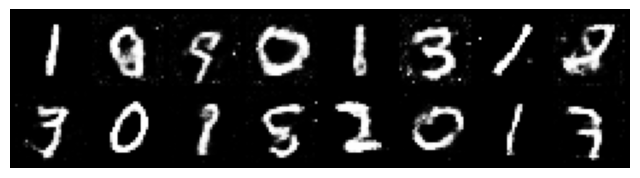

In [18]:
gerador_vgan.eval()
discriminador_vgan.eval()

with torch.no_grad():
    z = ruido(num_teste_amostra)
    fake_final = gerador_vgan(z)
    imagens_final = vetor_para_imagem(fake_final).cpu()

logger = Logger(model_name='VGAN_visualizacao_final', data_name='MNIST')

logger.display_images(imagens_final, num_teste_amostra, 0, 0, 0)


## Visualização

Para visualizar como a geração de imagens evolui ao longo do treinamento, as amostras geradas em diferentes épocas são organizadas em sequência temporal. A cada época, o gerador produz imagens a partir de um vetor de ruído fixo, permitindo uma comparação consistente entre os estados do modelo ao longo do tempo.

Ao transformar essas imagens em uma animação, é possível observar o processo de aprendizado de forma direta.

In [19]:
# Adendo: Caso o bloco abaixo não esteje rodando, execute esta instalação
# !{sys.executable} -m pip install imageio[ffmpeg]

In [20]:
pasta = "dados/imagens/VGAN/MNIST"

arquivos = sorted(
    [f for f in os.listdir(pasta) if f.endswith(".png")],
    key=lambda x: int(x.split("_")[1].split(".")[0])
)

frames = []
for arq in arquivos:
    caminho = os.path.join(pasta, arq)
    frames.append(imageio.imread(caminho))

os.makedirs("videos", exist_ok=True)

caminho_saida = "videos/evolucao_vgan_mnist.mp4"

if not os.path.exists(caminho_saida):
    imageio.mimsave(caminho_saida, frames, fps=3, macro_block_size=1, format="ffmpeg")

Video(caminho_saida, embed=True)

Inicialmente as saídas são aleatórias e sem estrutura, mas, conforme o treinamento avança, o Gerador passa a capturar progressivamente as características da distribuição dos dados reais.

Podemos também analisar o processo de aprendizado observando a evolução da loss do Gerador e do Discriminador ao longo do treinamento. Para isso, utilizaremos o tensorboard do `Logger` para extrair as curvas no formato `.csv` manualmente. Este processo já foi feito e os resultados foram dispostos em `csv_losses/VGAN`.

Caso tenham interesse, o código para abrir o tensorboard encontra-se abaixo.

In [21]:
# tb = program.TensorBoard()
# tb.configure(argv=[None, "--logdir", "runs/VGAN_MNIST"])
# print(tb.launch())

Plottando as curvas de evolução da loss:

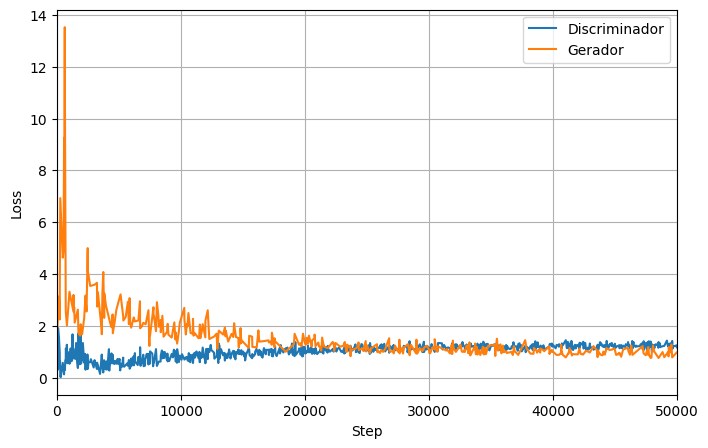

In [22]:
g_path = "csv_losses/VGAN/gerador.csv"
d_path = "csv_losses/VGAN/discriminador.csv"

g = pd.read_csv(g_path)
d = pd.read_csv(d_path)

plt.figure(figsize=(8, 5))

plt.plot(d["Step"], d["Value"], label="Discriminador")
plt.plot(g["Step"], g["Value"], label="Gerador")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.xlim(0, 50000)

plt.legend()
plt.grid()

plt.show()

Percebe-se que no início a loss do Discriminador era baixa. Isso é esperado, pois ele ainda conseguia distinguir facilmente dados reais de dados gerados artificialmente.

Ao longo do treino, essa loss aumentou. Isso indica que o Discriminador começou a ter mais dificuldade em separar real de falso, pois o Gerador foi melhorando sua capacidade de gerar amostras plausíveis. Essa análise é confirmada ao observar que com o passar das iterações a loss do Gerador foi abaixando enquanto que a do Discriminador foi aumentando, com eles eventualmente convergindo.

# Aviso: Leia antes de continuar

A partir deste ponto, assume-se que o leitor já esteja familiarizado com o funcionamento e a implementação de redes do tipo GAN. Assim, a apresentação do código e a análise dos resultados serão mais concisas, sem detalhamento extensivo, partindo da expectativa de compreensão prévia do tema.

# <span style="color:red">CGAN</span>

As **Conditional Generative Adversarial Networks (CGANs)** foram propostas por Mehdi Mirza e Simon Osindero em 2014, como uma extensão das GANs tradicionais [10]. A principal modificação introduzida por esse modelo é a inclusão de informação condicional, como rótulos de classe, tanto no Gerador quanto no Discriminador. Isso permite que o modelo não apenas aprenda a gerar dados realistas, mas também a controlar explicitamente as características do que está sendo gerado. Dessa forma, essas redes ampliam significativamente a aplicabilidade das GANs, especialmente em tarefas como geração condicionada de imagens e tradução entre domínios.

O dataset que iremos trabalhar será o **MNIST**, o mesmo que foi utilizado na VGAN.

Definiremos inicialmente a função `one_hot`, responsável por transformar os rótulos das classes em representações vetoriais. Essa etapa é necessária pois a rede condicional não trabalha diretamente com valores escalares de classe, mas sim com uma representação vetorial que possa ser concatenada aos demais vetores de entrada. Dessa forma, cada rótulo inteiro (0 a 9) é convertido em um vetor de dimensão 10, no qual apenas a posição correspondente à classe possui valor 1, enquanto as demais permanecem 0.

In [23]:
def one_hot(labels, num_classes=10):
    return nn.functional.one_hot(labels, num_classes).float()

As arquiteturas das redes Discriminador e Gerador permanecem as mesmas do exemplo da VGAN, com o único diferencial de que a entrada original é concatenada com o vetor one-hot do rótulo de dimensão 10, formando uma entrada conjunta.

Essa concatenação permite que o Discriminador não apenas diferencie imagens reais de falsas, mas também verifique a coerência entre a imagem e a classe associada, avaliando se a amostra gerada corresponde corretamente ao rótulo informado. Consequentemente, o Gerador passa a ser capaz de produzir amostras específicas para cada classe, aprendendo uma distribuição condicional dos dados, isto é, a relação entre o ruído latente e as características de cada categoria [11].

In [24]:
class Discriminador_cgan(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784 + 10, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x, y):
        y = one_hot(y).to(x.device)
        x = torch.cat([x, y], dim=1)
        return self.model(x)


class Gerador_cgan(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(100 + 10, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z, y):
        y = one_hot(y).to(z.device)
        x = torch.cat([z, y], dim=1)
        return self.model(x)

Podemos instanciar os modelos.

In [25]:
discriminador_cgan = Discriminador_cgan()
gerador_cgan = Gerador_cgan()

E colocar um condicional para carregar os pesos dos modelos salvos na pasta `dados/modelos/CGAN/MNIST` caso ele já tenha sido treinado.

In [26]:
checkpoint_dir = "./dados/modelos/CGAN/MNIST"
epochs = []

if os.path.exists(checkpoint_dir):
    arquivos = os.listdir(checkpoint_dir)

    for arq in arquivos:
        if arq.startswith("G_epoch_") and arq.endswith(".pt"):
            num = arq.replace("G_epoch_", "").replace(".pt", "")
            if num.isdigit():
                epochs.append(int(num))

if len(epochs) == 0:
    print("Nenhum checkpoint encontrado. Treinando do zero.")
    epoch_start = 0

else:
    epoch_start = max(epochs) + 1

    print(f"Checkpoint encontrado. Carregando época {epoch_start - 1}.")

    gerador_cgan.load_state_dict(torch.load(
        f"{checkpoint_dir}/G_epoch_{epoch_start - 1}.pt",
        map_location=dispositivo
    ))

    discriminador_cgan.load_state_dict(torch.load(
        f"{checkpoint_dir}/D_epoch_{epoch_start - 1}.pt",
        map_location=dispositivo
    ))

    print("Modelos carregados com sucesso.")

Checkpoint encontrado. Carregando época 200.
Modelos carregados com sucesso.


Assim como na VGAN, o otimizador usado em ambas as redes será o `Adam` com taxa de aprendizado de `0.0002`.

In [27]:
d_otimizador = optim.Adam(discriminador_cgan.parameters(), lr=0.0002)
g_otimizador = optim.Adam(gerador_cgan.parameters(), lr=0.0002)

Além disso, será necessário criar uma função auxiliadora que gera rótulos aleatórios para condicionar o Gerador durante o treino.

In [28]:
def amostra_rotulos(n):
    return torch.randint(0, 10, (n,), device=dispositivo)

As funções de treinamento do Discriminador e do Gerador seguem a mesma lógica utilizada na VGAN, com a diferença de que, na versão condicional, ambos os modelos também recebem o rótulo da classe como entrada.

In [29]:
def treina_discriminador(opt, real_x, real_y, fake_x, fake_y):
    opt.zero_grad()

    pred_real = discriminador_cgan(real_x, real_y)
    erro_real = loss(pred_real, real_data_target(real_x.size(0)))

    pred_fake = discriminador_cgan(fake_x, fake_y)
    erro_fake = loss(pred_fake, fake_data_target(fake_x.size(0)))

    erro = erro_real + erro_fake
    erro.backward()
    opt.step()

    return erro, pred_real, pred_fake


def treina_gerador(opt, fake_x, fake_y):
    opt.zero_grad()

    pred = discriminador_cgan(fake_x, fake_y)
    erro = loss(pred, real_data_target(pred.size(0)))

    erro.backward()
    opt.step()

    return erro

Com tudo definido corretamente, podemos prosseguir para o treinamento.

In [30]:
gerador_cgan = gerador_cgan.to(dispositivo)
discriminador_cgan = discriminador_cgan.to(dispositivo)

if epoch_start == 0:
    logger = Logger(model_name='CGAN', data_name='MNIST')

for epoch in range(epoch_start, num_epochs + 1):

    for n_batch, (real_batch, labels) in enumerate(loader):

        real_data = imagem_para_vetor(real_batch).to(dispositivo)
        labels = labels.to(dispositivo)

        z = ruido(real_data.size(0))

        fake_labels = labels
        fake_data = gerador(z, fake_labels).detach()

        d_erro, d_pred_real, d_pred_fake = treina_discriminador(d_otimizador, real_data, labels, fake_data, fake_labels)

        z = ruido(real_data.size(0))

        fake_labels = amostra_rotulos(real_data.size(0))
        fake_data = gerador_cgan(z, fake_labels)

        g_erro = treina_gerador(g_otimizador, fake_data, fake_labels)
        
        logger.log(d_erro, g_erro, epoch, n_batch, num_batches)

        if n_batch % 100 == 0:
            clear_output(wait=True)

            with torch.no_grad():
                z_test = ruido(num_teste_amostra)

                y_test = torch.arange(0, 10).repeat(2)[:num_teste_amostra].to(dispositivo)

                teste_imagens = vetor_para_imagem(
                    gerador_cgan(z_test, y_test)
                ).cpu()

            logger.display_images(teste_imagens, num_teste_amostra, epoch, n_batch, num_batches)
            logger.log_images(teste_imagens, num_teste_amostra, epoch, n_batch, num_batches)
            logger.display_status(epoch, num_epochs, n_batch, num_batches, d_erro, g_erro, d_pred_real, d_pred_fake)

    if epoch == epoch_start or epoch % 100 == 0:
        logger.save_models(gerador_cgan, discriminador_cgan, epoch)

    if epoch == epoch_start or epoch % 5 == 0:
        with torch.no_grad():
            z_test = ruido(num_teste_amostra)
            y_test = torch.arange(0, 10).repeat(2)[:num_teste_amostra].to(dispositivo)

            teste_imagens = vetor_para_imagem(
                gerador_cgan(z_test, y_test)
            ).cpu()

        logger.save_epoch_images(teste_imagens, epoch)

Após o término do treinamento, podemos colocar os modelos em modo de avaliação para realizar inferência com o modelo treinado e observar os resultados.

Nesta etapa, define-se explicitamente uma lista de rótulos (`lista_rotulos`), que indica quais classes devem ser geradas pelo modelo. O tamanho da lista determina automaticamente o número de imagens produzidas. Para cada rótulo, um vetor de ruído é amostrado e combinado com a classe correspondente, permitindo que o Gerador produza imagens condicionadas. Dessa forma, é possível controlar diretamente o tipo de saída do modelo, gerando exemplos específicos de cada classe desejada.

Sinta-se livre para brincar com CGAN abaixo!

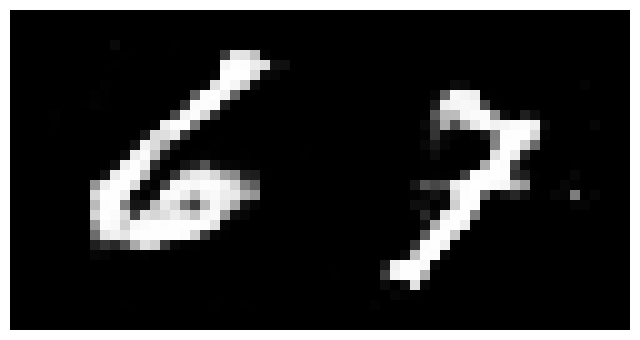

In [58]:
gerador_cgan.eval()

with torch.no_grad():
    lista_rotulos = [6, 7] # Rótulos das classes a gerar; sinta-se livre para modificar o tamanho e os valores da lista!
    
    num_imgs = len(lista_rotulos)
    z = ruido(num_imgs).to(dispositivo)

    y = torch.tensor(lista_rotulos).to(dispositivo)
    
    imgs = gerador_cgan(z, y)
    imgs = vetor_para_imagem(imgs).cpu()

logger = Logger(model_name="CGAN_visualizacao_final", data_name="MNIST")

logger.display_images(imgs, num_imgs, 0, 0, 0)

## Visualização

De forma análoga ao que foi feito anteriormente, podemos observar a evolução das imagens conforme o treinamento avança.

In [32]:
pasta = "dados/imagens/CGAN/MNIST"

arquivos = sorted(
    [f for f in os.listdir(pasta) if f.endswith(".png")],
    key=lambda x: int(x.split("_")[1].split(".")[0])
)

frames = []
for arq in arquivos:
    caminho = os.path.join(pasta, arq)
    frames.append(imageio.imread(caminho))

os.makedirs("videos", exist_ok=True)

caminho_saida = "videos/evolucao_cgan_mnist.mp4"

if not os.path.exists(caminho_saida):
    imageio.mimsave(caminho_saida, frames, fps=3, macro_block_size=1, format="ffmpeg")

Video(caminho_saida, embed=True)

Além dos plots de evolução da loss.

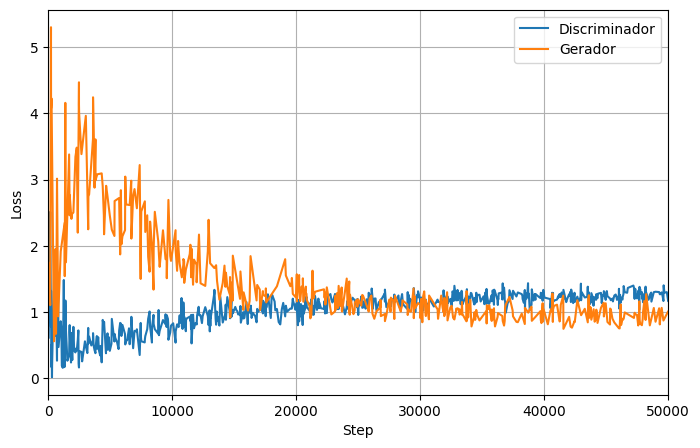

In [33]:
g_path = "csv_losses/CGAN/gerador.csv"
d_path = "csv_losses/CGAN/discriminador.csv"

g = pd.read_csv(g_path)
d = pd.read_csv(d_path)

plt.figure(figsize=(8, 5))

plt.plot(d["Step"], d["Value"], label="Discriminador")
plt.plot(g["Step"], g["Value"], label="Gerador")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.xlim(0, 50000)

plt.legend()
plt.grid()

plt.show()

Percebe-se que os resultados obtidos são bastante semelhantes aos da VGAN.

# <span style="color:red">DCGAN</span>

As **Deep Convolutional Generative Adversarial Networks (DCGANs)** foram propostas por Radford, Metz e Chintala em 2015 como uma extensão das GANs tradicionais, com o objetivo de aumentar a estabilidade do treinamento e melhorar a qualidade das amostras geradas [12]. A principal modificação introduzida por esse modelo é a substituição de camadas totalmente conectadas por arquiteturas baseadas em **redes neurais convolucionais (CNNs)** profundas, tanto no Gerador quanto no Discriminador. Essa escolha permite explorar melhor a estrutura espacial dos dados, especialmente em imagens, aproveitando propriedades como invariância a translações e hierarquias de características visuais [12].

Além disso, as DCGANs introduzem um conjunto de restrições arquiteturais que se tornaram padrão em modelos generativos baseados em CNNs, como o uso de convoluções transpostas no Gerador para realizar *upsampling*, convoluções *strided* no Discriminador para redução progressiva de dimensionalidade, e a substituição de *pooling* por operações convolucionais aprendíveis. Também é comum o uso de `Batch Normalization` e funções de ativação como `LeakyReLU`, o que contribui para reduzir instabilidades como colapso de modo durante o treinamento [13].

Dessa forma, as DCGANs representam um marco importante na integração entre GANs e CNNs, sendo amplamente utilizadas como base para arquiteturas mais avançadas em geração de imagens. Como não faz parte do escopo desse trabalho, caso o leitor deseje uma compreensão mais ampla das redes convolucionais e seus fundamentos, recomenda-se consultar os trabalhos feitos por outros estudantes na **Trilha da Acadêmica** à respeito das CNNs.

O dataset que iremos trabalhar será o **MNIST**, o mesmo que foi utilizado nas redes anteriores.

Definiremos primeiro as classes do Gerador e do Discriminador. O Gerador recebe um vetor de ruído de dimensão 100, que é projetado e reestruturado em um tensor de 256×7×7, seguido por camadas de convolução transposta que realizam o aumento progressivo da resolução e a redução dos canais até gerar uma imagem final com 1 canal.

O Discriminador realiza o processo inverso, aplicando camadas convolucionais que reduzem a resolução espacial e aumentam os canais, extraindo características hierárquicas até produzir uma única saída que indica a probabilidade da imagem ser real ou gerada

In [34]:
class Gerador_dcgan(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear = nn.Linear(100, 256 * 7 * 7)

        self.conv1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True)
        )

        self.conv2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, True)
        )

        self.out = nn.Sequential(
            nn.Conv2d(64, 1, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.linear(x)
        x = x.view(x.size(0), 256, 7, 7)

        x1 = self.conv1(x)
        x2 = self.conv2(x1)

        out = self.out(x2)
        return out


class Discriminador_dcgan(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, True)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True)
        )

        self.out = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x1 = self.conv1(x)
        x2 = self.conv2(x1)

        out = self.out(x2)
        return out

Em DCGANs, a inicialização dos pesos é um ponto importante para a estabilidade do treinamento, já que o modelo é sensível a oscilações no fluxo de gradientes. Por isso, é comum aplicar uma estratégia de inicialização controlada, como a distribuição normal com média próxima de zero para camadas convolucionais e valores específicos para a Batch Normalization [13].

In [35]:
def pesos_iniciais(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

Podemos instanciar os modelos e aplicar os pesos.

In [36]:
discriminador_dcgan = Discriminador_dcgan()
discriminador_dcgan.apply(pesos_iniciais)
gerador_dcgan = Gerador_dcgan()
gerador_dcgan.apply(pesos_iniciais)

Gerador_dcgan(
  (linear): Linear(in_features=100, out_features=12544, bias=True)
  (conv1): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv2): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (out): Sequential(
    (0): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Tanh()
  )
)

E colocar um condicional para carregar os pesos dos modelos salvos na pasta `dados/modelos/DCGAN/MNIST` caso ele já tenha sido treinado.

In [37]:
checkpoint_dir = "./dados/modelos/DCGAN/MNIST"
epochs = []

if os.path.exists(checkpoint_dir):
    arquivos = os.listdir(checkpoint_dir)

    for arq in arquivos:
        if arq.startswith("G_epoch_") and arq.endswith(".pt"):
            num = arq.replace("G_epoch_", "").replace(".pt", "")
            if num.isdigit():
                epochs.append(int(num))

if len(epochs) == 0:
    print("Nenhum checkpoint encontrado. Treinando do zero.")
    epoch_start = 0

else:
    epoch_start = max(epochs) + 1

    print(f"Checkpoint encontrado. Carregando época {epoch_start - 1}.")

    gerador_dcgan.load_state_dict(torch.load(
        f"{checkpoint_dir}/G_epoch_{epoch_start - 1}.pt",
        map_location=dispositivo
    ))

    discriminador_dcgan.load_state_dict(torch.load(
        f"{checkpoint_dir}/D_epoch_{epoch_start - 1}.pt",
        map_location=dispositivo
    ))

    print("Modelos carregados com sucesso.")

Checkpoint encontrado. Carregando época 200.
Modelos carregados com sucesso.


Assim como nas outras redes, o otimizador utilizado será o `Adam`, com taxa de aprendizado de `0.0002`. Entretanto, neste caso são definidos parâmetros de *momentum* via `betas=(0.5, 0.999)`, o que controla a média móvel dos gradientes e de suas variações. Essa escolha é padrão em DCGANs, pois ajuda a estabilizar o treinamento adversarial e reduzir oscilações durante a atualização simultânea do Gerador e do Discriminador [13].

In [38]:
d_otimizador = optim.Adam(discriminador_dcgan.parameters(), lr=0.0002, betas=(0.5, 0.999))
g_otimizador = optim.Adam(gerador_dcgan.parameters(), lr=0.0002, betas=(0.5, 0.999))

Definimos as funções de treino de maneira muito similar à usada na VGAN (já que neste caso não se utiliza rótulos como na CGAN).

In [39]:
def treina_discriminador(otimizador, real_data, fake_data):
    otimizador.zero_grad()

    pred_real = discriminador_dcgan(real_data)
    erro_real = loss(pred_real, real_data_target(real_data.size(0)))
    erro_real.backward()

    pred_fake = discriminador_dcgan(fake_data)
    erro_fake = loss(pred_fake, fake_data_target(fake_data.size(0)))
    erro_fake.backward()

    otimizador.step()

    return erro_real + erro_fake, pred_real, pred_fake

def treina_gerador(otimizador, fake_data):
    otimizador.zero_grad()

    pred = discriminador_dcgan(fake_data)

    erro = loss(pred, real_data_target(pred.size(0)))
    erro.backward()

    otimizador.step()

    return erro
    

Com tudo definido corretamente, podemos prosseguir para o treinamento.

In [40]:
if epoch_start == 0:
    logger = Logger(model_name='DCGAN', data_name='MNIST')

gerador_dcgan = gerador_dcgan.to(dispositivo)
discriminador_dcgan = discriminador_dcgan.to(dispositivo)

for epoch in range(epoch_start, num_epochs+1):

    for n_batch, (real_batch, _) in enumerate(loader):

        real_data = real_batch.to(dispositivo)

        z = ruido(real_data.size(0))
        fake_data = gerador_dcgan(z).detach()

        d_erro, d_pred_real, d_pred_fake = treina_discriminador(d_otimizador, real_data, fake_data)

        z = ruido(real_batch.size(0))
        fake_data = gerador_dcgan(z)

        g_erro = treina_gerador(g_otimizador, fake_data)
    
        logger.log(d_erro, g_erro, epoch, n_batch, num_batches)

        if n_batch % 100 == 0:
            clear_output(wait=True)
            with torch.no_grad():
                teste_imagens = gerador_dcgan(ruido_teste).cpu()

            logger.display_images(teste_imagens, num_teste_amostra, epoch, n_batch, num_batches)
            logger.log_images(teste_imagens, num_teste_amostra, epoch, n_batch, num_batches)
            logger.display_status(epoch, num_epochs, n_batch, num_batches, d_erro, g_erro, d_pred_real, d_pred_fake)

    if epoch == epoch_start or epoch % 100 == 0:
        logger.save_models(gerador_dcgan, discriminador_dcgan, epoch)

    if epoch == epoch_start or epoch <= 5 or epoch % 5 == 0:
        with torch.no_grad():
            teste_imagens = gerador_dcgan(ruido_teste).cpu()
    
        logger.save_epoch_images(teste_imagens, epoch)

Após o término do treinamento, podemos colocar os modelos em modo de avaliação para realizar inferência com o modelo treinado e observar os resultados.

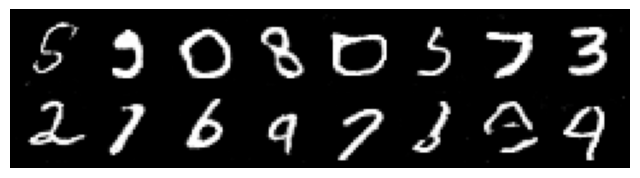

In [41]:
gerador_dcgan.eval()
discriminador_dcgan.eval()

with torch.no_grad():
    z = ruido(num_teste_amostra)
    fake_final = gerador_dcgan(z)
    imagens_final = fake_final.cpu()
    
logger = Logger(model_name='DCGAN_visualizacao_final', data_name='MNIST')

logger.display_images(imagens_final, num_teste_amostra, 0, 0, 0)


## Visualização

De forma análoga ao que foi feito anteriormente, podemos observar a evolução das imagens conforme o treinamento avança.

In [42]:
pasta = "dados/imagens/DCGAN/MNIST"

arquivos = sorted(
    [f for f in os.listdir(pasta) if f.endswith(".png")],
    key=lambda x: int(x.split("_")[1].split(".")[0])
)

frames = []
for arq in arquivos:
    caminho = os.path.join(pasta, arq)
    frames.append(imageio.imread(caminho))

os.makedirs("videos", exist_ok=True)

caminho_saida = "videos/evolucao_dcgan_mnist.mp4"

if not os.path.exists(caminho_saida):
    imageio.mimsave(caminho_saida, frames, fps=3, macro_block_size=1, format="ffmpeg")

Video(caminho_saida, embed=True)

Pode-se observar que a dinâmica de treinamento da DCGAN difere um pouco das GANs tradicionais, apresentando, em geral, maior estabilidade na convergência dos algarismos. 

Além disso, podemos realizar os plots de evolução da loss.

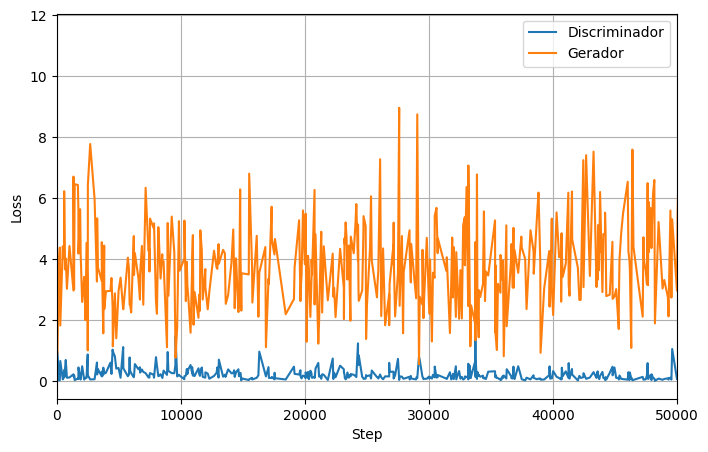

In [43]:
g_path = "csv_losses/DCGAN/gerador.csv"
d_path = "csv_losses/DCGAN/discriminador.csv"

g = pd.read_csv(g_path)
d = pd.read_csv(d_path)

plt.figure(figsize=(8, 5))

plt.plot(d["Step"], d["Value"], label="Discriminador")
plt.plot(g["Step"], g["Value"], label="Gerador")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.xlim(0, 50000)

plt.legend()
plt.grid()

plt.show()

Percebe-se que a loss do Discriminador permaneceu menor que a do Gerador ao longo do treinamento. Apesar disso, ambas se estabilizar após algumas épocas, indicando um certo equilíbrio dinâmico entre as redes. Nesse cenário, o Discriminador continua exercendo pressão sobre o Gerador, forçando-o a melhorar progressivamente a qualidade das amostras geradas para conseguir “enganar” a rede adversária. 

# Outros tipos de GANs

Fora as arquiteturas abordadas neste trabalho, existem diversos outros tipos de GANs na literatura, cada uma com adaptações específicas para diferentes tarefas [1]. Entre elas, destacam-se as **StyleGANs**, voltadas para geração de imagens de alta qualidade com controle detalhado de atributos visuais; as **CycleGANs**, utilizadas principalmente para tradução de imagens entre domínios não pareados; e as **Pix2Pix GANs**, aplicadas em tarefas de tradução imagem-para-imagem supervisionadas.

# Discussão dos resultados

Na análise dos resultados, observa-se que VGAN e CGAN apresentaram comportamentos bastante semelhantes, com curvas de loss oscilando de forma contínua ao longo do treinamento. Em ambas, o Discriminador tende a manter valores de loss menores que o Gerador no início do treino, indicando que ele consegue distinguir com mais facilidade as amostras reais das geradas. Entretanto, com o passar das épocas, a loss do Gerador diminui progressivamente enquanto a do Discriminador aumenta, até que ambas passam a se aproximar e alternar sua dominância. Esse comportamento reflete o equilíbrio adversarial característico das GANs, no qual o avanço de uma rede força a outra a se ajustar continuamente.

Por outro lado, a DCGAN apresentou uma estabilização mais rápida das curvas de loss, com menor variabilidade ao longo das épocas. Nesse caso, o Discriminador permanece com loss inferior à do Gerador, o que, em teoria, contraria o comportamento mais equilibrado esperado em um treinamento adversarial ideal, no qual ambas as redes deveriam evoluir de forma mais competitiva e próxima.

No entanto, esse comportamento sugere uma dinâmica de aprendizado parcialmente “forçada” no Gerador, já que como o Discriminador se mantém relativamente mais eficiente, o Gerador é constantemente pressionado a se ajustar para reduzir sua perda, o que pode acelerar a convergência, mas também indicar que ele ainda não alcança plenamente a capacidade de enganar o Discriminador de forma consistente. De qualquer modo, isso evidencia que os parâmetros e escolhas arquiteturais, especialmente no caso da DCGAN, devem ser cuidadosamente ajustados e explorados para extrair seu potencial máximo.

# Conclusão

Conclui-se que as Redes Generativas Adversariais (GANs) representam uma abordagem altamente relevante para tarefas de geração de dados, especialmente em imagens. Ao longo deste trabalho, foi possível observar que diferentes variações do modelo (VGAN, CGAN e DCGAN) apresentam comportamentos distintos em termos de estabilidade de treinamento, convergência das losses, qualidade das amostras geradas e aplicabilidade. De forma geral, as GANs se mostram úteis por sua capacidade de aprender distribuições complexas de dados sem necessidade de supervisão explícita completa, sendo amplamente aplicáveis em problemas de síntese de imagens.

# <span style="color:rebeccapurple">Adendo sobre a atividade bônus</span>

Devido a problemas técnicos relacionados ao uso do `Git LFS` no fork da biblioteca real, não foi possível incluir os arquivos correspondentes a essa parte do projeto.

Conforme descrito no README, caso deseje acessar esses arquivos, consulte diretamente no repositório original no GitHub: https://github.com/ComicDeath/GANs

# <span style="color:rebeccapurple">Bônus - Aplicação de uma DCGAN</span>

Essa parte é apresentada como um bônus, demonstrando a aplicação de uma DCGAN em um problema específico de geração de imagens dentro de um contexto **EXTREMAMENTE IMPORTANTE**. 

### Gerar garotas de anime... 

Esse código foi fortemente inspirado em projetos previamente desenvolvidos em repositórios públicos [14, 15]. O Dataset foi construído por meio de um *scraper* que percorre sites do tipo *booru*, como o `Getchu` e o `Safebooru`, realizando o download das imagens disponíveis. Em seguida, foi aplicada a ferramenta `lbpcascade_animeface` [16], responsável por detectar e recortar automaticamente os rostos das personagens. O tamanho final do Dataset ficou em cerca de 60 mil imagens de rostos (contendo alguns *outliers*, é claro) de garotas de anime.

Note-se que, neste caso, foi utilizado o espaço de cores RGB, diferentemente do conjunto **MNIST**, no qual as imagens são em escala de cinza (grayscale).

In [44]:
class AnimeDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.paths = [os.path.join(root, f) for f in os.listdir(root) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = PILImage.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

dataset = AnimeDataset("dataset/anime/imagens", transform=transform)

dataloader_anime = DataLoader(dataset, batch_size=100, shuffle=True)

A arquitetura das redes foi inspirada nas apresentadas em [2, 14], seguindo os mesmos princípios estruturais já discutidos anteriormente. Dessa forma, opta-se por não detalhar intrisicamente suas componentes, uma vez que o funcionamento geral do Gerador e do Discriminador já foi bem discutido nos exemplos passado. Deixa-se esse exercício para o leitor atento.

O único apontamento relevante diz respeito à escolha das funções de ativação. Neste exemplo, a utilização de `LeakyReLU` no Discriminador e `ReLU` no Gerador não é arbitrária; ela está diretamente associada à estabilidade do treinamento adversarial. O Discriminador utiliza o `LeakyReLU` para mitigar o problema de *dying neurons*, garantindo a preservação do fluxo de gradientes mesmo para ativações negativas, o que mantém sua capacidade de discriminação ao longo do treinamento [17].

Por outro lado, o Gerador emprega `ReLU` nas camadas internas por favorecer ativações mais estáveis e eficientes na construção progressiva das representações a partir do vetor de ruído. Essa combinação contribui para um melhor equilíbrio no fluxo de gradientes entre as redes, evitando saturações no Discriminador e permitindo que o Gerador aprenda estruturas cada vez mais complexas de forma gradual [17]. 

Esse ponto é importante pois a ausência desse detalhamento e a escolha inadequada inicial foram erros cometidos na primeira DCGAN apresentada previamente neste trabalho. Aqui, registro também o aprendizado decorrente dessa etapa e as minhas sinceras desculpas por essa omissão inicial.

In [45]:
class Gerador_dcgan_anime(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear = nn.Linear(100, 512 * 4 * 4)

        self.conv1 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True)
        )

        self.conv2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True)
        )

        self.conv3 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True)
        )

        self.conv4 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True)
        )

        self.out = nn.Sequential(
            nn.Conv2d(32, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.linear(x)
        x = x.view(x.size(0), 512, 4, 4)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        return self.out(x)
        
class Discriminador_dcgan_anime(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, True)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, True)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, True)
        )

        self.out = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        return self.out(x)

Mesma lógica dos exemplos passados.

In [46]:
discriminador_anime = Discriminador_dcgan_anime()
discriminador_anime.apply(pesos_iniciais)
gerador_anime = Gerador_dcgan_anime()
gerador_anime.apply(pesos_iniciais)

Gerador_dcgan_anime(
  (linear): Linear(in_features=100, out_features=8192, bias=True)
  (conv1): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv3): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv4): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, trac

In [47]:
checkpoint_dir = "./dados/modelos/DCGAN-ANIME/ANIME"
epochs = []

if os.path.exists(checkpoint_dir):
    arquivos = os.listdir(checkpoint_dir)

    for arq in arquivos:
        if arq.startswith("G_epoch_") and arq.endswith(".pt"):
            num = arq.replace("G_epoch_", "").replace(".pt", "")
            if num.isdigit():
                epochs.append(int(num))

if len(epochs) == 0:
    print("Nenhum checkpoint encontrado. Treinando do zero.")
    epoch_start = 0

else:
    epoch_start = max(epochs) + 1

    print(f"Checkpoint encontrado. Carregando época {epoch_start - 1}.")

    gerador_anime.load_state_dict(torch.load(
        f"{checkpoint_dir}/G_epoch_{epoch_start - 1}.pt",
        map_location=dispositivo
    ))

    discriminador_anime.load_state_dict(torch.load(
        f"{checkpoint_dir}/D_epoch_{epoch_start - 1}.pt",
        map_location=dispositivo
    ))

    print("Modelos carregados com sucesso.")

Checkpoint encontrado. Carregando época 200.
Modelos carregados com sucesso.


In [48]:
d_otimizador = optim.Adam(discriminador_anime.parameters(), lr=0.0002, betas=(0.5, 0.999))
g_otimizador = optim.Adam(gerador_anime.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [49]:
if epoch_start == 0:
    logger = Logger(model_name='DCGAN-ANIME', data_name='ANIME')

gerador_anime = gerador_anime.to(dispositivo)
discriminador_anime = discriminador_anime.to(dispositivo)

for epoch in range(epoch_start, num_epochs+1):

    for n_batch, real_batch in enumerate(dataloader_anime):

        real_data = real_batch.to(dispositivo)

        z = ruido(real_data.size(0))
        fake_data = gerador_anime(z).detach()

        d_erro, d_pred_real, d_pred_fake = treina_discriminador(d_otimizador, real_data, fake_data)

        z = ruido(real_batch.size(0))
        fake_data = gerador_anime(z)

        g_erro = treina_gerador(g_otimizador, fake_data)

        logger.log(d_erro, g_erro, epoch, n_batch, num_batches)

        if n_batch % 100 == 0:
            clear_output(wait=True)
            with torch.no_grad():
                teste_imagens = gerador_anime(ruido_teste).cpu()

            logger.display_images(teste_imagens, num_teste_amostra, epoch, n_batch, num_batches)
            logger.log_images(teste_imagens, num_teste_amostra, epoch, n_batch, num_batches)
            logger.display_status(epoch, num_epochs, n_batch, num_batches, d_erro, g_erro, d_pred_real, d_pred_fake)

    if epoch == epoch_start or epoch % 5 == 0:
        logger.save_models(gerador_anime, discriminador_anime, epoch)

    if epoch == epoch_start or epoch <= 5 or epoch % 5 == 0:
        with torch.no_grad():
            teste_imagens = gerador_anime(ruido_teste).cpu()
    
        logger.save_epoch_images(teste_imagens, epoch)

Após o término do treinamento, podemos colocar os modelos em modo de avaliação para realizar inferência com o modelo treinado e observar os resultados.

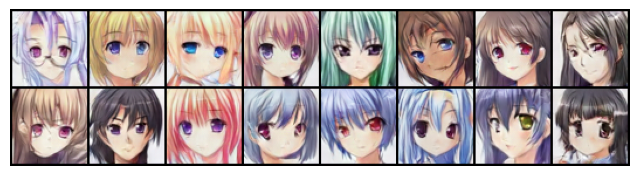

In [57]:
gerador_anime.eval()
discriminador_anime.eval()

with torch.no_grad():
    z = ruido(num_teste_amostra)
    fake_final = gerador_anime(z)
    imagens_final = fake_final.cpu()
    
logger = Logger(model_name='DCGAN-ANIME_visualizacao_final', data_name='ANIME')

logger.display_images(imagens_final, num_teste_amostra, 0, 0, 0)


De forma análoga ao que foi feito anteriormente, podemos observar a evolução das imagens conforme o treinamento avança.

In [51]:
pasta = "dados/imagens/DCGAN-ANIME/ANIME"

arquivos = sorted(
    [f for f in os.listdir(pasta) if f.endswith(".png")],
    key=lambda x: int(x.split("_")[1].split(".")[0])
)

frames = []
for arq in arquivos:
    caminho = os.path.join(pasta, arq)
    frames.append(imageio.imread(caminho))

os.makedirs("videos", exist_ok=True)

caminho_saida = "videos/evolucao_dcgan_anime.mp4"

if not os.path.exists(caminho_saida):
    imageio.mimsave(caminho_saida, frames, fps=3, macro_block_size=1, format="ffmpeg")

Video(caminho_saida, embed=True)

Conclui-se aqui este trabalho, com um **ÓTIMO exemplo** das capacidades das redes generativas adversariais e de seu potencial em diferentes aplicações de geração de dados.

# Referências

[1] VARUGHESE, J - **Generative Adversarial Networks**. Disponível em: <https://www.ibm.com/think/topics/generative-adversarial-networks>.

[2] DIEGO GOMEZ MOSQUERA - **GANs from Scratch 1: A deep introduction**. Disponível em: <https://medium.com/ai-society/gans-from-scratch-1-a-deep-introduction-with-code-in-pytorch-and-tensorflow-cb03cdcdba0f>.

[3] ANSON - **The coolest idea in deep learning in 20 years and more**. Disponível em: <https://trendsandevents4developers.wordpress.com/2017/04/24/the-coolest-idea-in-deep-learning-in-20-years-and-more/>. 

[4] AWS — **Explicação sobre redes adversárias generativas.** Disponível em: <https://aws.amazon.com/pt/what-is/gan/>.

[5] NASHORY. GitHub - **gans-awesome-applications**. Disponível em: <https://github.com/nashory/gans-awesome-applications>.

[6] GOODFELLOW, I. J. et al. - **Generative Adversarial Networks**. Disponível em: <https://arxiv.org/abs/1406.2661>.

[7] DIEGOALEJOGM. GitHub - **Generative Adversarial Networks implemented in PyTorch and Tensorflow.** Disponível em: <https://github.com/diegoalejogm/gans>. 

[8] Torchvision 0.24 documentation - **MNIST**. Disponível em: <https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html>.

[9] CHINTALA, S. - **soumith/ganhacks**. Disponível em: <https://github.com/soumith/ganhacks>.

[10] MIRZA, M.; OSINDERO, S. - **Conditional Generative Adversarial Nets**. Disponível em: <https://arxiv.org/abs/1411.1784>.

[11] AVIKUMAR TALAVIYA - **Introduction to conditional GANs**. Disponível em: <https://medium.com/ai-science/introduction-to-conditional-gans-8f855b7048cd>

[12] RADFORD, A.; METZ, L.; CHINTALA, S. - **Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks**. Disponível em: <https://arxiv.org/abs/1511.06434>.

[13] MANOHAR KEDAMSETTI. - **Implementing DCGAN in PyTorch using the CelebA Dataset: A Comprehensive Guide**. Disponível em: <https://medium.com/@manoharmanok/implementing-dcgan-in-pytorch-using-the-celeba-dataset-a-comprehensive-guide-660e6e8e29d2>.

[14] JAYLEICN. GitHub - **A simple PyTorch Implementation of Generative Adversarial Networks, focusing on anime face drawing**. Disponível em: <https://github.com/jayleicn/animeGAN/>.

[15] Bryan Chao. GitHub - **A collection of high-quality anime faces**. Disponível em: <https://github.com/bchao1/Anime-Face-Dataset>.

[16] NAGADOMI. GitHub - **A Face detector for anime/manga using OpenCV**. Disponível em: <https://github.com/nagadomi/lbpcascade_animeface>.

[17] MUSTAFA604 - **GANs Part2: DCGAN**. Disponível em: <https://medium.com/@Mustafa77/gans-specialization-part2-a79e7d4b85e4>.